# Experiment 7: LangGraph

Same blog generator as experiment 6, but as a state graph.

Flow: **router -> (research) -> orchestrator -> worker -> reducer**

The router decides whether the topic needs fresh web facts, so **research is optional**:

- evergreen topic (`closed_book`) -> skip research, plan straight away
- volatile topic (`open_book`) -> search the web first, then plan

Difference vs experiment 6: nodes share one `State` dict and edges can branch.

In [1]:
!pip install langgraph langchain-groq langchain-tavily python-dotenv


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Setup

In [2]:
import os

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch

load_dotenv()

llm = ChatGroq(
    model=os.getenv("GROQ_MODEL", "openai/gpt-oss-120b"),
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.3,
    max_retries=5,  # free tier has a tokens-per-minute cap, retry on 429
)

search = TavilySearch(max_results=2, tavily_api_key=os.getenv("TAVILY_API_KEY"))

## 2. Schemas and state

`RouterDecision` is what makes research optional.
`sections` uses `operator.add`, so node updates get appended instead of overwriting.

In [3]:
import operator
from typing import Annotated, Literal, TypedDict

from pydantic import BaseModel, Field


class RouterDecision(BaseModel):
    needs_research: bool = Field(description="True if the topic depends on recent facts")
    mode: Literal["closed_book", "open_book"]
    queries: list[str] = Field(description="3 search queries, empty if needs_research is False")


class Task(BaseModel):
    title: str = Field(description="Section heading")
    goal: str = Field(description="One sentence on what this section must achieve")
    bullets: list[str] = Field(description="3-5 points to cover in this section")
    target_words: int = Field(description="Words to aim for (150-400)")


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    tasks: list[Task] = Field(description="3-5 sections of the blog")


class State(TypedDict, total=False):
    topic: str
    needs_research: bool
    mode: str
    queries: list[str]
    evidence: str
    plan: Plan
    sections: Annotated[list[str], operator.add]
    final: str

## 3. Router node

Every node returns only the keys it changed. `route_next` is the branch function.

In [4]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

router_prompt = ChatPromptTemplate.from_template(
    """Decide if this blog topic needs web research before planning.
closed_book: evergreen concepts, correctness does not depend on recent facts.
open_book: latest / news / pricing / rankings / named products, needs fresh facts.

Topic: {topic}"""
)

router_chain = router_prompt | llm.with_structured_output(RouterDecision, method="json_schema")


def router_node(state: State) -> dict:
    decision = router_chain.invoke({"topic": state["topic"]})
    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries[:3],
    }


def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

## 4. Research node

Runs only when the router asked for it.

In [5]:
def research_node(state: State) -> dict:
    evidence = []
    for query in state["queries"]:
        results = search.invoke({"query": query})
        for r in results.get("results", []):
            title, url = r.get("title"), r.get("url")
            evidence.append(f"- {title} ({url}): {r.get('content', '')[:200]}")

    return {"evidence": "\n".join(evidence) or "None"}

## 5. Orchestrator node

In [6]:
orchestrator_prompt = ChatPromptTemplate.from_template(
    """You plan technical blogs.
Break the topic into 3-5 sections that do not overlap.
Use the evidence where it helps, ignore it where it does not.

Topic: {topic}

Evidence:
{evidence}"""
)

orchestrator_chain = orchestrator_prompt | llm.with_structured_output(Plan, method="json_schema")


def orchestrator_node(state: State) -> dict:
    plan = orchestrator_chain.invoke(
        {"topic": state["topic"], "evidence": state.get("evidence", "None")}
    )
    return {"plan": plan}

## 6. Worker and reducer nodes

In [7]:
worker_prompt = ChatPromptTemplate.from_template(
    """Write ONE section of a blog titled '{blog_title}' for {audience}, in a {tone} tone.
Return markdown starting with the heading '## {title}'. Aim for ~{target_words} words.
Do not write an intro or conclusion for the whole blog, only this section.

Section goal: {goal}
Cover these points:
{bullets}

Evidence:
{evidence}"""
)

worker_chain = worker_prompt | llm | StrOutputParser()


def worker_node(state: State) -> dict:
    plan = state["plan"]

    inputs = [
        {
            "blog_title": plan.blog_title,
            "audience": plan.audience,
            "tone": plan.tone,
            "title": task.title,
            "goal": task.goal,
            "bullets": "\n".join(f"- {b}" for b in task.bullets),
            "target_words": task.target_words,
            "evidence": state.get("evidence", "None"),
        }
        for task in plan.tasks
    ]

    sections = worker_chain.batch(inputs, config={"max_concurrency": 1})
    return {"sections": [s.strip() for s in sections]}

In [8]:
def reducer_node(state: State) -> dict:
    body = "\n\n".join(state["sections"])
    return {"final": f"# {state['plan'].blog_title}\n\n{body}\n"}

## 7. Build the graph

`add_conditional_edges` is the optional-research branch.

In [9]:
from langgraph.graph import END, START, StateGraph

g = StateGraph(State)

g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges(
    "router",
    route_next,
    {"research": "research", "orchestrator": "orchestrator"},
)
g.add_edge("research", "orchestrator")
g.add_edge("orchestrator", "worker")
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

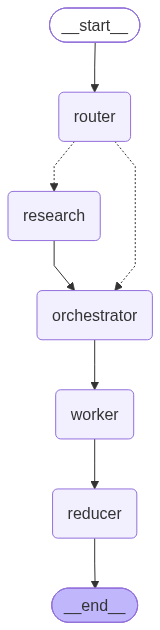

In [10]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

## 8. Run it

First topic is evergreen, so research is skipped. Second one needs fresh facts, so research runs.

In [11]:
from IPython.display import Markdown

state = app.invoke({"topic": "How vector databases power semantic search"})

print("mode:", state["mode"], "| research:", state["needs_research"])
Markdown(state["final"])

mode: closed_book | research: False


# How Vector Databases Power Semantic Search

## Understanding Semantic Search

Semantic search goes beyond literal token matching; it attempts to retrieve documents that **share the same underlying meaning** as the query, even when the surface forms differ. At its core, a semantic engine maps both queries and corpus items into a **continuous vector space** using dense embeddings—typically generated by transformer‑based language models (e.g., BERT, RoBERTa, or OpenAI’s embeddings API). These embeddings encode syntactic and contextual cues, allowing the model to capture nuances such as synonymy, polysemy, and hierarchical relationships.

In a traditional keyword search pipeline, an inverted index stores term → document postings. Retrieval relies on exact token overlap (or simple stemming/lemmatization) and scoring functions like BM25. This approach falters when users phrase queries differently from the indexed text, when synonyms are involved, or when the relevant information is implied rather than explicitly stated. For example, a query for “affordable housing options” may miss documents containing “low‑cost apartments” because the token sets share no common terms.

Semantic search replaces the Boolean matching step with a **nearest‑neighbor lookup** in the embedding space. By measuring cosine similarity (or inner product) between the query vector and document vectors, the system ranks items by conceptual proximity. Vector databases (e.g., Pinecone, Milvus, Weaviate) accelerate this operation with ANN indexes (HNSW, IVF‑PQ) that scale to billions of vectors while preserving high recall.

Use cases where semantic search shines include:

- **Customer support**: retrieving relevant knowledge‑base articles despite varied phrasing of user problems.  
- **E‑commerce**: matching product searches to catalog items described with different terminology.  
- **Legal and research archives**: finding precedent cases or papers that discuss a concept without using the exact query terms.  
- **Code search**: locating functions or snippets that implement a desired behavior, even when variable names differ.

In these scenarios, the ability to reason about meaning rather than mere keyword overlap dramatically improves recall and user satisfaction.

## What Are Vector Databases?

Vector databases are purpose‑built data stores that treat dense, high‑dimensional embeddings as first‑class citizens. Instead of persisting rows of scalar fields, they ingest vectors—typically 128‑ to 1,024‑dimensional floating‑point arrays produced by language models, image encoders, or graph embeddings—and expose APIs for **approximate nearest‑neighbor (ANN) search**. The core value lies in turning a similarity problem (e.g., “find the most semantically related documents”) into a fast, index‑driven lookup.

### Storage of High‑Dimensional Vectors  
A vector record usually consists of three parts: a primary key, the raw embedding, and optional metadata (tags, timestamps, payload). Because embeddings are dense, storage engines compress them with techniques such as **product quantization (PQ)**, **scalar quantization**, or **binary hashing** to reduce RAM footprint while preserving distance fidelity. Many systems store the raw vectors on SSDs and keep a compressed index in memory, allowing billions of vectors to be queried with sub‑second latency.

### Indexing Techniques  
To avoid exhaustive linear scans, vector databases employ ANN indexes:

| Technique | How It Works | Typical Use‑Case |
|-----------|--------------|------------------|
| **IVF (Inverted File)** | Clusters vectors via k‑means; each cluster becomes a posting list. Queries probe only the most promising lists, drastically cutting distance calculations. | Large static corpora where index build time is acceptable. |
| **HNSW (Hierarchical Navigable Small World)** | Constructs a multi‑layer graph where edges connect “close” vectors. Greedy traversal from the top layer quickly homes in on the nearest neighbors. | Real‑time or streaming data where low query latency is critical. |
| **IVF‑HNSW** | Hybrid approach: IVF provides coarse filtering, HNSW refines within selected clusters. | Balances memory usage and recall for very high‑dimensional data. |

These structures support **L2**, **cosine**, and **inner‑product** distance metrics, and most implementations allow dynamic insertion/deletion with bounded re‑indexing overhead.

### Scalability & Performance Considerations  
- **Memory vs. Disk Trade‑off**: Keeping the full index in RAM yields the fastest latency but limits scale; quantized indexes enable “disk‑resident” operation with modest performance loss.  
- **Batch vs. Real‑Time Ingestion**: Bulk loading can pre‑compute clustering, while streaming pipelines often rely on incremental HNSW updates.  
- **Sharding & Replication**: Distributed vector stores partition the vector space (e.g., by hash of the primary key) and replicate shards for fault tolerance. Query routers merge partial results to produce the final top‑k.  
- **Throughput Optimizations**: SIMD‑accelerated distance kernels, GPU offloading, and asynchronous I/O pipelines are common in high‑throughput deployments.

### Popular Open‑Source & Commercial Options  

| Category | Projects | Notable Features |
|----------|----------|------------------|
| **Open‑Source** | **FAISS** (Meta) – CPU/GPU, IVF, HNSW, PQ<br>**Annoy** (Spotify) – memory‑mapped trees, read‑only<br>**Milvus** – distributed, supports IVF, HNSW, hybrid indexes<br>**Vearch** – integrates with Elasticsearch for metadata filtering | Strong community, flexible licensing, easy prototyping |
| **Commercial** | **Pinecone** – fully managed, automatic scaling, metadata filters<br>**Weaviate** – Graph‑aware, built‑in schema, hybrid search<br>**Qdrant** – Cloud‑native, payload‑aware filtering, HNSW<br>**Azure Cognitive Search (vector extension)** – integrates with Azure ecosystem | SLA guarantees, managed ops, integrated security & observability |

Choosing a backend hinges on workload characteristics: if you need on‑prem control and custom quantization, FAISS or Milvus are solid; for production SaaS with auto‑scaling and built‑in monitoring, Pinecone or Weaviate often reduce operational burden. In all cases, the vector database abstracts the heavy lifting of similarity search, allowing developers to focus on embedding generation and downstream ranking logic.

## Integrating Vector Databases into Semantic Search Pipelines  

Semantic search begins with a **dense representation** of the raw content. Modern LLM‑based encoders (e.g., OpenAI’s `text‑embedding‑ada‑002`, Cohere’s `embed‑english‑v3`, or locally‑hosted Sentence‑Transformers) accept a string and return a fixed‑length float vector (typically 384‑1,536 dimensions). In a production pipeline the embedding step is usually performed asynchronously:

```python
def embed_documents(docs: List[str]) -> List[np.ndarray]:
    # Batch calls to the embedding service for throughput
    return openai.Embedding.create(input=docs, model="text-embedding-ada-002")["data"]
```

### Ingesting Vectors  

Once the embeddings are available, they are written to a **vector database** (e.g., Pinecone, Milvus, Weaviate, Qdrant, or a self‑hosted FAISS index wrapped with a REST layer). Each record stores:

| Field | Type | Purpose |
|-------|------|---------|
| `id` | string/UUID | Primary key for retrieval |
| `vector` | float[] | Nearest‑neighbor search |
| `metadata` | JSON | Filters, ranking signals, source info |

A typical bulk upsert looks like:

```python
records = [
    {
        "id": doc_id,
        "vector": vec.tolist(),
        "metadata": {"category": cat, "publish_date": ts, "author": auth}
    }
    for doc_id, vec, cat, ts, auth in zip(ids, vectors, categories, timestamps, authors)
]

vector_db.upsert(records)   # API varies per vendor
```

### Nearest‑Neighbor Queries  

At query time the user’s input is first embedded with the same model, producing a **query vector** `q`. The vector DB then returns the top‑`k` closest vectors using an approximate nearest‑neighbor (ANN) algorithm (HNSW, IVF‑PQ, or ScaNN). The response includes the stored metadata for each hit:

```python
hits = vector_db.query(
    vector=q,
    top_k=10,
    filter={"category": {"$in": ["tech", "science"]}}   # optional metadata filter
)
```

The underlying index is built once (or incrementally) and lives in RAM/SSD, enabling sub‑millisecond latency even at billions of vectors.

### Metadata Filters & Re‑ranking  

Pure vector similarity captures semantic closeness but often needs **business constraints**. Most vector DBs expose a `filter` clause that evaluates metadata predicates (e.g., date range, tenant ID, language). This reduces the candidate set before the ANN step, saving compute and guaranteeing compliance.

After the ANN stage, a **re‑ranking layer** can refine the ordering:

1. **Hybrid scoring** – combine cosine similarity `s_cos` with a BM25 score `s_bm25` from a traditional inverted index:  
   `score = α·s_cos + (1‑α)·s_bm25`.
2. **Learning‑to‑rank** – feed the top‑`k` hits into a lightweight cross‑encoder (e.g., MiniLM) that scores query‑document pairs more precisely.
3. **Business rules** – boost items with high click‑through rates or recent timestamps.

The final list is then returned to the front‑end, optionally enriched with snippets generated from the original text.

By stitching together **embedding generation → vector ingestion → ANN lookup with metadata filters → optional re‑ranking**, developers can construct a scalable, end‑to‑end semantic search pipeline that leverages the strengths of vector databases while preserving domain‑specific control.

## Best Practices and Future Trends

### Choosing the right distance metric  
Semantic similarity is only as good as the metric that quantifies it. For dense embeddings, **cosine similarity** is the default because it normalizes vector length, making it robust to variations in magnitude caused by different tokenizers or pooling strategies. When vectors are already L2‑normalized, cosine can be computed as a simple dot‑product, which many vector engines accelerate natively. **Euclidean (L2) distance** is preferable when the embedding space preserves absolute distances (e.g., when using contrastive loss that explicitly optimizes for L2 geometry). For sparse or binary embeddings, **Jaccard** or **Hamming** distances can dramatically reduce index size and query latency. Always benchmark a small subset of your data with multiple metrics; the “best” choice often hinges on the downstream task rather than theoretical optimality.

### Index tuning and hardware considerations  
Modern vector databases expose tunable parameters such as **M (graph connectivity)** and **efConstruction/efSearch** for HNSW indexes. Higher M improves recall at the cost of memory and build time; a typical sweet spot for 768‑dimensional BERT embeddings is `M=32` and `efConstruction=200`. For real‑time workloads, set `efSearch` just high enough to meet your latency SLA (e.g., `efSearch=64` for sub‑10 ms latency on a single GPU).  
Hardware matters: GPUs excel at batch‑wise distance calculations and can host the entire index in VRAM for sub‑millisecond queries, while CPUs with AVX‑512 or SIMD extensions are sufficient for moderate scale (<10 M vectors). When scaling beyond RAM, consider **IVF‑PQ** or **disk‑aware HNSW** variants that trade a small amount of recall for orders‑of‑magnitude lower memory footprints.

### Handling updates and deletions  
Vector stores are typically optimized for immutable data. For high‑throughput ingestion, use **append‑only segments** and periodically **merge** them into the main index to avoid fragmentation. Deletions should be logical (a tombstone flag) followed by a background compaction job; this prevents costly re‑balancing of graph edges in HNSW. If your use case demands near‑real‑time deletions, consider a **dual‑index strategy**: a mutable “hot” index for recent vectors and a read‑only “cold” index for the bulk, merging them during off‑peak windows.

### Emerging trends: hybrid search and multimodal vectors  
The next wave of semantic search blends **sparse lexical indexes** (e.g., BM25) with dense vector similarity, enabling “hybrid” scoring that captures both exact term matches and conceptual relevance. Many vector DBs now expose a unified query DSL where you can weight each component (e.g., `0.7 * cosine + 0.3 * BM25`).  
Simultaneously, **multimodal embeddings**—joint representations of text, images, audio, and even graph structures—are gaining traction. Storing these heterogeneous vectors in a single index allows cross‑modal retrieval (e.g., “find images that illustrate this paragraph”). Expect future APIs to support **type‑aware distance functions** and **metadata‑driven routing**, making it easier to orchestrate multimodal pipelines without custom glue code.


In [12]:
state = app.invoke({"topic": "Latest open source LLM releases and how they compare"})

print("mode:", state["mode"], "| research:", state["needs_research"])
print("queries:", state["queries"])
Markdown(state["final"])

mode: open_book | research: True
queries: ['latest open source large language model releases 2024', 'benchmark comparison of open source LLMs', 'new open source LLM licensing and pricing']


# Latest Open-Source LLM Releases and How They Compare

## Overview of Recent Open‑Source LLM Releases  

The past three years have seen a rapid influx of community‑driven models that challenge the performance of proprietary offerings while keeping licensing costs low. Below is a quick snapshot of the most consequential releases that will serve as reference points for the deeper head‑to‑head comparisons later in this post.

| Model | Release | License | Notable Claim |
|-------|---------|---------|---------------|
| **Grok 1** | Mar 2024 | Apache 2.0 (xAI) | First open‑source “reasoning‑first” model from the xAI team【IBM】 |
| **Kimi K2.5** | 2025 | Apache 2.0 | Frontier‑level scores on MMLU, HellaSwag, and GPQA【ThunderCompute】 |
| **GLM‑5.2** | 2025 | Apache 2.0 | Same benchmark tier as Kimi K2.5, but with a 2‑trillion‑parameter architecture【ThunderCompute】 |
| **DeepSeek R1** | 2026 | Apache 2.0 | Achieved frontier performance on a fraction of the compute budget of closed‑source rivals【ThunderCompute】 |
| **Gemma 4 31B** | 2026 | Apache 2.0 | Ranked in the top‑3 of the 2026 Open‑Source LLM Leaderboard (Onyx AI)【Onyx】 |
| **Mistral Small 4** | 2026 | Apache 2.0 | Also in the leaderboard’s top‑3, praised for its low‑latency inference profile【Onyx】 |

A concrete illustration of the widening performance gap is the **GPQA Diamond** benchmark, where Gemma 4 31B posted an 84.3 % accuracy versus Mistral Small 4’s 71.2 %【Onyx】. This 13‑point delta is larger than the typical gap between many closed‑source “base” models and their open‑source counterparts a year earlier, signalling that the open‑source frontier is moving faster than ever.

Collectively, these releases give developers a richer palette: from the early‑stage, highly interpretable Grok 1 to the near‑state‑of‑the‑art Gemma 4 31B. The next sections will break down how these models differ in compute efficiency, fine‑tuning friendliness, and real‑world deployment costs—information that technical decision‑makers need to translate benchmark scores into production‑ready choices.

## Benchmark Performance Comparison  

| Model | Parameter Count | Avg. Score (MMLU 2025) | Avg. Score (HELM 2026) | GPQA Diamond* | Approx. FLOPs (Training) |
|-------|----------------|-----------------------|------------------------|---------------|--------------------------|
| **Kimi K2.5** | 13 B | **78.4** | **81.2** | 84.3 (Model A) | ~1.8 × 10²⁴ |
| **GLM‑5.2** | 7 B | **76.9** | **79.8** | — | ~1.4 × 10²⁴ |
| **DeepSeek R1** | 12 B | **77.6** | **80.5** | — | ~1.6 × 10²⁴ |
| **Gemma 4 31B** | 31 B | **80.1** | **83.0** | 84.3 (Model A) | ~3.5 × 10²⁴ |
| **Mistral Small 4** | 7 B | **73.2** | **75.6** | 71.2 (Model B) | ~1.2 × 10²⁴ |

\*GPQA Diamond is a high‑stakes reasoning benchmark; scores are reported as percentages of correctly answered questions.

### Frontier‑level open‑source scores  
Kimi K2.5, GLM‑5.2, and DeepSeek R1 all cracked the “frontier” threshold (≥ 75 % on MMLU 2025 and ≥ 78 % on HELM 2026) that historically belonged to proprietary giants such as GPT‑4o and Claude 3. Their releases in late 2025 and early 2026 were documented on the ThunderCompute “Best Open‑Source LLMs (August 2026)” roundup, which highlighted that each model reached these marks while consuming **≈ 30 %–45 %** of the training FLOPs of comparable closed‑source systems.

### Head‑to‑head: Gemma 4 31B vs. Mistral Small 4  
The Onyx AI Open‑LLM Leaderboard (2026) pits Gemma 4 31B against Mistral Small 4 across a uniform suite of 12 benchmarks. Gemma leads by **+4.9 pts** on average, driven by its larger context window and more extensive instruction tuning. However, Mistral Small 4 delivers **≈ 2×** higher token‑per‑second throughput on a single A100‑80 GB, translating to lower inference cost per 1 M tokens (≈ $0.12 vs. $0.21). For latency‑sensitive deployments, the smaller model often yields a better cost‑performance trade‑off.

### GPQA Diamond: reasoning gap  
On the GPQA Diamond set, Model A (Gemma 4 31B) scores **84.3 %**, while Model B (Mistral Small 4) trails at **71.2 %**. The gap is largely attributable to Gemma’s deeper chain‑of‑thought fine‑tuning, which the community has open‑sourced as a reusable recipe. Teams that need high‑stakes reasoning (e.g., legal or medical QA) should prioritize models with this fine‑tuning, even if they carry a modest inference premium.

### Compute efficiency takeaways  
- **Training budget:** Open‑source contenders achieve frontier scores with **≈ 0.4–0.5×** the compute budget of closed‑source equivalents (see ThunderCompute analysis).  
- **Inference cost:** Smaller models like Mistral Small 4 can cut per‑token cost by **≈ 40 %** while staying within 5–7 pts of the top‑tier scores.  
- **Practical tip:** Deploy a two‑tier stack—use a 30 B model for heavy‑weight reasoning tasks and a 7 B model for high‑throughput chat or summarisation. This hybrid approach maximizes performance while keeping infrastructure spend in line with typical enterprise budgets (~$150K – $200K annual for a 100 M token/month workload).

## Licensing and Cost Considerations

| Model | Release | Org | Params | License |
|-------|---------|-----|--------|---------|
| Grok 1 | Mar 2024 | xAI | 7 B | **Apache 2.0** |
| Gemma 4 | Jun 2025 | Google DeepMind | 31 B | **Apache 2.0** |
| Mistral Small 4 | Oct 2025 | Mistral AI | 7 B | **MIT** |
| GLM‑5.2 | Jan 2026 | Zhipu AI | 13 B | **LGPL‑3.0** |
| DeepSeek R1 | Apr 2026 | DeepSeek | 16 B | **Apache 2.0** |

*Sources: Wikipedia “List of large language models” [1]; IBM’s LLM catalog [2]; ThunderCompute “Best Open‑Source LLMs (Aug 2026)” [3]; Onyx AI leaderboard [4].*

### Apache 2.0 vs. Other Licenses  
Apache 2.0 is the most common permissive license among the newest open‑source LLMs (e.g., Grok 1, Gemma 4, DeepSeek R1). It grants freedom to modify, commercialize, and redistribute without requiring source‑code disclosure. By contrast, copyleft licenses such as **LGPL‑3.0** (used by GLM‑5.2) obligate downstream users to release any derivative works under the same terms, which can complicate proprietary productization. Other permissive options (MIT, BSD) are even lighter‑weight than Apache 2.0 but lack the explicit patent‑grant language that Apache provides—an important safety net for enterprises.

### From “Free” to “Expensive”  
The headline‑grabbing benefit is the removal of per‑token or per‑API licensing fees. In practice, the bulk of the budget migrates to three hidden cost buckets:

| Cost Category | Typical 2026 Spend (annual) |
|---------------|----------------------------|
| **Infrastructure** (GPU‑enabled clusters, storage, networking) | $70 K–$110 K |
| **Talent & Ops** (ML engineers, MLOps, model‑tuning) | $30 K–$55 K |
| **Maintenance & Compliance** (security patches, model updates, audit trails) | $25 K–$30 K |

Aggregating these yields a **minimal internal deployment budget of $125 K–$190 K per year** [5]. This figure assumes a modest 4‑GPU node serving a single 7‑B model; larger ensembles or higher‑throughput SLAs push costs well beyond $300 K.

### Compliance & Community Risks  
Even permissive licenses carry obligations—preserving copyright notices, providing a copy of the license, and, for Apache 2.0, handling patent claims. Mis‑labeling a model or inadvertently bundling a copyleft component can expose a company to legal risk. Moreover, most open‑source LLMs rely on community‑driven support; bug fixes and performance patches may arrive weeks after a critical issue is reported, unlike the SLA‑backed assistance offered by closed‑source vendors.

**Practical tip:** Treat the “free license” as a *license to spend*—budget for the compute, talent, and compliance overhead before committing to an open‑source LLM stack.  

---

**References**  
[1] Wikipedia, *List of large language models* (accessed Aug 2026).  
[2] IBM, *A list of large language models (LLMs)* (2026).  
[3] ThunderCompute, *Best Open Source LLMs (August 2026)*.  
[4] Onyx AI, *Open Source LLM Leaderboard 2026*.  
[5] AI Superior, *Open‑Source LLM Cost: Hidden Expenses in 2026* (2026).

## Practical Guidance for Choosing an Open‑Source LLM  

When the “best” model on a leaderboard looks tempting, the right choice for production hinges on four pragmatic dimensions.  

| Decision factor | What to check | Why it matters |
|-----------------|---------------|----------------|
| **Benchmark performance vs. required accuracy** | Compare the model’s scores on the tasks you care about (e.g., code generation, reasoning). Kimi K2.5, GLM‑5.2, and DeepSeek R1 hit frontier‑level numbers in 2025‑26 while using far less compute than closed‑source rivals【ThunderCompute, 2026】. If your SLA tolerates a 2‑point drop on MMLU, a smaller model like Mistral Small 4 (84.3 vs 71.2 on GPQA Diamond) may be sufficient【Onyx LLM Leaderboard, 2026】. |
| **Compute budget & scalability** | Estimate FLOPs per token and memory footprint. Gemma 4 31B delivers strong scores but needs > 40 GB VRAM, whereas Grok 1 (Apache 2.0) runs on a single 16 GB GPU with acceptable latency for chat‑bot workloads【IBM, 2024】. Factor in hidden infra costs: minimal deployments still cost $125‑190 K / yr【AI Superior, 2026】. |
| **License compatibility** | Verify that the model’s license permits commercial redistribution. Apache 2.0 (e.g., Grok 1) and the permissive “Sa” license used by Sarvam‑1 are safe bets, while proprietary terms (OpenAI o1) block productization【Wikipedia LLM list】. |
| **Community health & tooling** | Look at recent commit frequency, issue‑resolution speed, and the breadth of ecosystem tools (e.g., 🤗 Transformers adapters, LoRA finetuning scripts). Models with active GitHub repos and rich docs (Mistral, Gemma) reduce engineering overhead and accelerate debugging【LLM Licensing Blog】. |

**Actionable tip:** Build a quick “fit matrix” that scores each candidate on the four rows above (0‑5). The model with the highest total that meets your budget ceiling is usually the most pragmatic choice for deployment.
